In [ ]:
# Appendix comparison overview

This notebook compares **our sample** against the published variability measurements from **MacLeod+2010** and **Stone+2021/2022** (matched-source analyses and diagnostic plots).

Before running the analysis cells, you must run: `setup_data --apendix`.

In [176]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import astropy.units as u

from astropy.io import fits
from astropy.coordinates import SkyCoord

from qvc.hubble.hubble_utils import load_agn_data, match_radec, read_quasars_from_hdf5_flat
from qvc.hubble.cuts import (
    LOG_SIGMA_UV_MIN,
    LOG_SIGMA_UV_MAX,
    LOG_TAU_UV_RF_MIN,
    LOG_TAU_UV_RF_MAX,
)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = False


In [177]:
AGN_H5 = "../results/data/apr18h_taufasttoslow150_chisq_N1w500s200t12ch1.h5"
SPECTRA_FIT_CSV = ["../results/data/jaxqsofit_apr14a_chisq20_apr9a.csv"]
macleod_DIR = Path("../data/s82drw")
BANDS = ["u", "g", "r", "i"]
BAND = "r"
MATCH_RADIUS_ARCSEC = 1.0

PLOT_PATH = "/tmp/qvc_macleod_compare_apr11a"
CUT_REPORT_PATH = "/tmp/qvc_macleod_compare_apr11a/cut_report.txt"

macleod_COLUMNS = [
    "SDR5ID",
    "ra",
    "dec",
    "redshift",
    "M_i",
    "mass_BH_Msun",
    "chi2_pdf",
    "log10_tau_days",
    "log10_sigma_mag_sqrt_yr",
    "log10_tau_lim_lo",
    "log10_tau_lim_hi",
    "log10_sig_lim_lo",
    "log10_sig_lim_hi",
    "edge_flag",
    "Plike",
    "Pnoise",
    "Pinf",
    "mu",
    "npts",
]


In [178]:
quasar_list = read_quasars_from_hdf5_flat(AGN_H5)
df_agn = pd.DataFrame(quasar_list)
df_agn['object_id'] = df_agn['object_id'].astype(str)
print(list(df_agn.keys()))


['LOGL5100', 'LOGL5100_ERR', 'LOGLBOL', 'LOGLBOL_CORRECTED', 'LOGLBOL_CORRECTED_ERR', 'LOGLBOL_ERR', 'SN_MEDIAN_ALL', 'adf_any_pvalue_lt_0p05', 'adf_min_pvalue', 'adf_nobs_g', 'adf_nobs_i', 'adf_nobs_r', 'adf_nobs_u', 'adf_pvalue_g', 'adf_pvalue_i', 'adf_pvalue_r', 'adf_pvalue_u', 'adf_stat_g', 'adf_stat_i', 'adf_stat_r', 'adf_stat_u', 'adf_usedlag_g', 'adf_usedlag_i', 'adf_usedlag_r', 'adf_usedlag_u', 'adf_valid_g', 'adf_valid_i', 'adf_valid_r', 'adf_valid_u', 'alpha_high_ls', 'alpha_high_ls_err', 'amp_bc_g', 'amp_bc_g_err', 'amp_bc_i', 'amp_bc_i_err', 'amp_bc_r', 'amp_bc_r_err', 'amp_bc_u', 'amp_bc_u_err', 'amp_blr2_g', 'amp_blr2_g_err', 'amp_blr2_i', 'amp_blr2_i_err', 'amp_blr2_r', 'amp_blr2_r_err', 'amp_blr2_u', 'amp_blr2_u_err', 'amp_blr_g', 'amp_blr_g_err', 'amp_blr_i', 'amp_blr_i_err', 'amp_blr_r', 'amp_blr_r_err', 'amp_blr_u', 'amp_blr_u_err', 'amp_cont_g', 'amp_cont_g_err', 'amp_cont_i', 'amp_cont_i_err', 'amp_cont_r', 'amp_cont_r_err', 'amp_cont_u', 'amp_cont_u_err', 'bands_g

In [ ]:

MACLEOD_YEAR_DAYS = 365.25

def read_macleod_band(band=BAND):
    path = macleod_DIR / f"s82drw_{band}.dat"
    df = pd.read_csv(path, comment="#", sep=r"\s+", header=None)
    df.columns = macleod_COLUMNS
    x_tau = pd.to_numeric(df["log10_tau_days"], errors="coerce").to_numpy(dtype=float)
    tau_lo = pd.to_numeric(df["log10_tau_lim_lo"], errors="coerce").to_numpy(dtype=float)
    tau_hi = pd.to_numeric(df["log10_tau_lim_hi"], errors="coerce").to_numpy(dtype=float)
    edge_flag = pd.to_numeric(df["edge_flag"], errors="coerce").to_numpy(dtype=float)
    xerr_low_tau = x_tau - tau_lo
    xerr_high_tau = tau_hi - x_tau
    valid_xerr_tau = (
        np.isfinite(xerr_low_tau) & np.isfinite(xerr_high_tau)
        & (xerr_low_tau >= 0.0) & (xerr_high_tau >= 0.0)
        & (tau_lo < tau_hi) & (tau_lo < x_tau) & (x_tau < tau_hi)
        & (edge_flag == 0)
    )
    valid_large_tau_hi = np.isfinite(xerr_high_tau) & np.isfinite(x_tau) #& (xerr_high_tau < 0.6 * x_tau)
    df = df.loc[valid_xerr_tau & valid_large_tau_hi].copy()
    df["band"] = band
    return df


def build_band_comparison(df_ours, band=BAND, max_sep_arcsec=MATCH_RADIUS_ARCSEC):
    macleod = read_macleod_band(band)
    matched, unmatched = match_radec(
        df_ours,
        macleod,
        populate_cols=[
            "SDR5ID",
            "redshift",
            "log10_tau_days",
            "log10_tau_lim_lo",
            "log10_tau_lim_hi",
            "log10_sigma_mag_sqrt_yr",
            "log10_sig_lim_lo",
            "log10_sig_lim_hi",
            "npts",
            "edge_flag",
            "chi2_pdf",
            "Plike",
            "Pnoise",
            "Pinf",
        ],
        max_sep_arcsec=max_sep_arcsec,
        add_prefix=True,
    )
    matched = matched[matched["matched_idx_b"] >= 0].copy()
    matched = matched.rename(
        columns={
            "matched_SDR5ID": f"macleod_SDR5ID_{band}",
            "matched_redshift": f"macleod_redshift_{band}",
            "matched_log10_tau_days": f"macleod_tau_obs_{band}",
            "matched_log10_tau_lim_lo": f"macleod_tau_obs_lo_{band}",
            "matched_log10_tau_lim_hi": f"macleod_tau_obs_hi_{band}",
            "matched_log10_sigma_mag_sqrt_yr": f"macleod_log_sigma_hat_catalog_{band}",
            "matched_log10_sig_lim_lo": f"macleod_sigma_obs_lo_{band}",
            "matched_log10_sig_lim_hi": f"macleod_sigma_obs_hi_{band}",
            "matched_npts": f"macleod_npts_{band}",
            "matched_edge_flag": f"macleod_edge_flag_{band}",
            "matched_chi2_pdf": f"macleod_chi2_pdf_{band}",
            "matched_Plike": f"macleod_Plike_{band}",
            "matched_Pnoise": f"macleod_Pnoise_{band}",
            "matched_Pinf": f"macleod_Pinf_{band}",
        }
    )
    macleod_redshift = pd.to_numeric(matched[f"macleod_redshift_{band}"], errors='coerce')
    redshift_log_factor = np.log10(1.0 + macleod_redshift.to_numpy(dtype=float))
    matched[f"macleod_sigma_{band}"] = (
        matched[f"macleod_log_sigma_hat_catalog_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_sigma_lo_{band}"] = (
        matched[f"macleod_sigma_obs_lo_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_sigma_hi_{band}"] = (
        matched[f"macleod_sigma_obs_hi_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_tau_{band}"] = matched[f"macleod_tau_obs_{band}"] #- redshift_log_factor
    matched[f"macleod_tau_lo_{band}"] = matched[f"macleod_tau_obs_lo_{band}"] #- redshift_log_factor
    matched[f"macleod_tau_hi_{band}"] = matched[f"macleod_tau_obs_hi_{band}"] #- redshift_log_factor
    matched[f"ours_sigma_{band}"] = matched[f"log_sigma_band_{band}"]
    matched[f"ours_sigma_{band}_err"] = matched[f"log_sigma_band_{band}_err"]
    matched[f"ours_tau_{band}"] = matched[f"log_tau_band_{band}_RF"]
    matched[f"ours_tau_{band}_err"] = matched[f"log_tau_band_{band}_RF_err"]
    matched[f"delta_log_sigma_{band}"] = matched[f"ours_sigma_{band}"] - matched[f"macleod_sigma_{band}"]
    matched[f"delta_log_tau_{band}"] = matched[f"ours_tau_{band}"] - matched[f"macleod_tau_{band}"]

    macleod_edge_flag = pd.to_numeric(matched[f"macleod_edge_flag_{band}"], errors='coerce')
    macleod_Plike = pd.to_numeric(matched[f"macleod_Plike_{band}"], errors='coerce')
    macleod_Pnoise = pd.to_numeric(matched[f"macleod_Pnoise_{band}"], errors='coerce')
    macleod_Pinf = pd.to_numeric(matched[f"macleod_Pinf_{band}"], errors='coerce')
    m10_quality_mask = (
        (macleod_edge_flag == 0)
        & ((macleod_Plike - macleod_Pnoise) > 2.0)
        & ((macleod_Plike - macleod_Pinf) > 0.05)
    )
    finite_range_mask = (
        matched[f"macleod_tau_{band}"].between(LOG_TAU_UV_RF_MIN, LOG_TAU_UV_RF_MAX)
        & matched[f"macleod_sigma_{band}"].between(LOG_SIGMA_UV_MIN, LOG_SIGMA_UV_MAX)
    )
    macleod_cut_mask =  finite_range_mask & m10_quality_mask
    matched_cut = matched[macleod_cut_mask].copy()
    return matched, matched_cut, macleod, unmatched


matched_by_band_all = {}
matched_by_band_subcut = {}
macleod_by_band = {}
unmatched_by_band = {}
for band in BANDS:
    matched_all, matched_subcut, macleod_band_df, unmatched_macleod_band = build_band_comparison(df_agn, band=band)
    matched_by_band_all[band] = matched_all
    matched_by_band_subcut[band] = matched_subcut
    macleod_by_band[band] = macleod_band_df
    unmatched_by_band[band] = unmatched_macleod_band

matched_r_all = matched_by_band_all["r"]
matched_r_subcut = matched_by_band_subcut["r"]
macleod_r = macleod_by_band["r"]
unmatched_object_ids = unmatched_by_band["r"]

print(f"MacLeod+2010 r-band rows: {len(macleod_r):,}")
print(f"Matched r-band rows: {len(matched_r_all):,}")
print(f"Matched r-band rows after MacLeod+2010 quality + sigma/tau cuts: {len(matched_r_subcut):,}")
print(f"Median match separation (all matched): {np.nanmedian(matched_r_all['matched_sep_arcsec']) if len(matched_r_all) else np.nan:.4f} arcsec")
for band in BANDS:
    print(
        f"{band}-band matched: {len(matched_by_band_all[band]):,} total, "
        f"{len(matched_by_band_subcut[band]):,} after MacLeod+2010 quality + sigma/tau cuts"
    )


MacLeod+2010 r-band rows: 7,661
Matched r-band rows: 2,994
Matched r-band rows after MacLeod+2010 quality + sigma/tau cuts: 2,455
Median match separation (all matched): 0.0549 arcsec
u-band matched: 3,256 total, 2,695 after MacLeod+2010 quality + sigma/tau cuts
g-band matched: 3,168 total, 2,715 after MacLeod+2010 quality + sigma/tau cuts
r-band matched: 2,994 total, 2,455 after MacLeod+2010 quality + sigma/tau cuts
i-band matched: 3,049 total, 2,317 after MacLeod+2010 quality + sigma/tau cuts


In [180]:
summary_rows = [
    {
        "sample": "ours matched (M10 quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['ours_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['ours_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['ours_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['ours_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
    {
        "sample": "M10 r matched (quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['macleod_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['macleod_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['macleod_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['macleod_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
    {
        "sample": "delta this work-M10 (quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['delta_log_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['delta_log_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['delta_log_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['delta_log_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

display(
    matched_r_all[[
        'object_id', 'ra', 'dec', 'z', 'ours_sigma_r', 'ours_tau_r',
        'macleod_SDR5ID_r', 'macleod_redshift_r', 'macleod_log_sigma_hat_catalog_r', 'macleod_sigma_r', 'macleod_tau_r',
        'delta_log_sigma_r', 'delta_log_tau_r', 'matched_sep_arcsec',
    ]].head()
)


,sample,n,sigma_median,sigma_std,tau_median,tau_std
0,ours matched (M10 quality cut),2455,-0.916309,0.201134,2.706382,0.343252
1,M10 r matched (quality cut),2455,-0.828377,0.230373,2.483126,0.406702
2,delta this work-M10 (quality cut),2455,-0.089236,0.209603,0.213879,0.452958


,object_id,ra,dec,z,ours_sigma_r,ours_tau_r,macleod_SDR5ID_r,macleod_redshift_r,macleod_log_sigma_hat_catalog_r,macleod_sigma_r,macleod_tau_r,delta_log_sigma_r,delta_log_tau_r,matched_sep_arcsec
4,1385478,44.963829,0.629330,0.470845,-1.034362,2.229026,6886,0.4707,-0.211254,-1.143553,0.831498,0.109191,1.397528,0.030122
6,1385482,44.954757,-0.140343,2.654386,-0.865725,2.657929,6884,2.6503,-0.718868,-0.190268,3.358491,-0.675457,-0.700562,0.139940
10,1385506,44.926812,0.027273,2.208783,-0.906135,2.288338,6879,2.2037,-0.06969,-0.646305,1.204738,-0.25983,1.0836,0.087899
13,1385521,44.906120,0.626776,0.534538,-1.145199,2.791600,6871,0.5337,-0.275351,-1.059986,1.10861,-0.085213,1.68299,0.029560
18,1385534,44.890536,-0.421603,1.754754,-0.856838,2.980448,6868,1.7586,-0.433097,-0.824822,1.639481,-0.032016,1.340967,0.096806


In [181]:
TOP_N = 10

print(f'Top {TOP_N} |delta_log_sigma_r| MacLeod+2010 outliers (all matched)')
display(
    matched_r_all.reindex(matched_r_all['delta_log_sigma_r'].abs().sort_values(ascending=False).index)[[
        'object_id', 'ra', 'dec', 'z', 'ours_sigma_r', 'macleod_log_sigma_hat_catalog_r', 'macleod_sigma_r',
        'delta_log_sigma_r', 'matched_sep_arcsec',
    ]].head(TOP_N)
)

print(f'Top {TOP_N} |delta_log_tau_r| MacLeod+2010 outliers (all matched)')
display(
    matched_r_all.reindex(matched_r_all['delta_log_tau_r'].abs().sort_values(ascending=False).index)[[
        'object_id', 'ra', 'dec', 'z', 'ours_tau_r', 'macleod_tau_r',
        'delta_log_tau_r', 'matched_sep_arcsec',
    ]].head(TOP_N)
)


Top 10 |delta_log_sigma_r| MacLeod+2010 outliers (all matched)


,object_id,ra,dec,z,ours_sigma_r,macleod_log_sigma_hat_catalog_r,macleod_sigma_r,delta_log_sigma_r,matched_sep_arcsec
5990,1419335,20.300589,-0.510288,1.658067,-1.154823,-0.812109,0.075141,-1.229964,0.078308
7585,1427895,13.583284,0.457762,2.511390,-0.252137,-1.23028,-1.363365,1.111228,0.002566
7804,1429146,12.507547,0.438921,1.948263,-1.241994,-0.994465,-0.205505,-1.036489,0.086709
3090,1402965,32.403825,-0.371192,2.395097,-1.172635,-0.955528,-0.175678,-0.996957,0.053819
767,1390021,41.300519,-1.220566,2.470709,-1.212100,-1.10946,-0.268745,-0.943354,0.079205
15618,1458920,333.603753,0.202810,1.469203,-1.225556,-0.81516,-0.282345,-0.94321,0.095035
7631,1428168,13.350325,0.259133,1.410495,-1.235050,-1.00947,-0.30356,-0.931489,0.069080
736,1389887,41.381403,-0.436727,2.076330,-1.196407,-1.12775,-0.27197,-0.924437,0.070669
3741,1407176,29.275161,-0.055512,1.543450,-0.969511,-0.756805,-0.04825,-0.92126,0.076287
17906,1465408,321.484435,0.760951,0.281369,-0.199079,-0.403735,-1.11594,0.916861,0.078733


Top 10 |delta_log_tau_r| MacLeod+2010 outliers (all matched)


,object_id,ra,dec,z,ours_tau_r,macleod_tau_r,delta_log_tau_r,matched_sep_arcsec
3174,1403466,32.052696,0.698832,0.694268,2.760716,-0.7511,3.511816,0.026175
2262,1397309,36.271110,0.292578,2.414940,3.417076,0.037655,3.379422,0.010988
2043,1396263,37.002678,0.453234,2.397972,3.102560,-0.225813,3.328373,0.057226
909,1390664,40.870258,0.641955,2.762727,3.142775,-0.147613,3.290388,0.189007
17728,1464956,322.319205,0.632419,2.960925,2.369519,-0.811716,3.181235,0.082561
7036,1424918,15.968635,0.627721,0.703495,3.530696,0.479881,3.050815,0.128404
13974,1454330,342.462176,-0.752590,1.358812,2.444236,-0.606063,3.0503,0.063841
9761,1440223,3.835612,0.454615,3.692491,2.970881,-0.076991,3.047872,0.046148
15711,1459211,333.071995,0.540825,2.269781,3.470683,0.433682,3.037,0.066008
16658,1462080,327.492505,0.191064,2.133205,2.771230,-0.20499,2.97622,0.147002


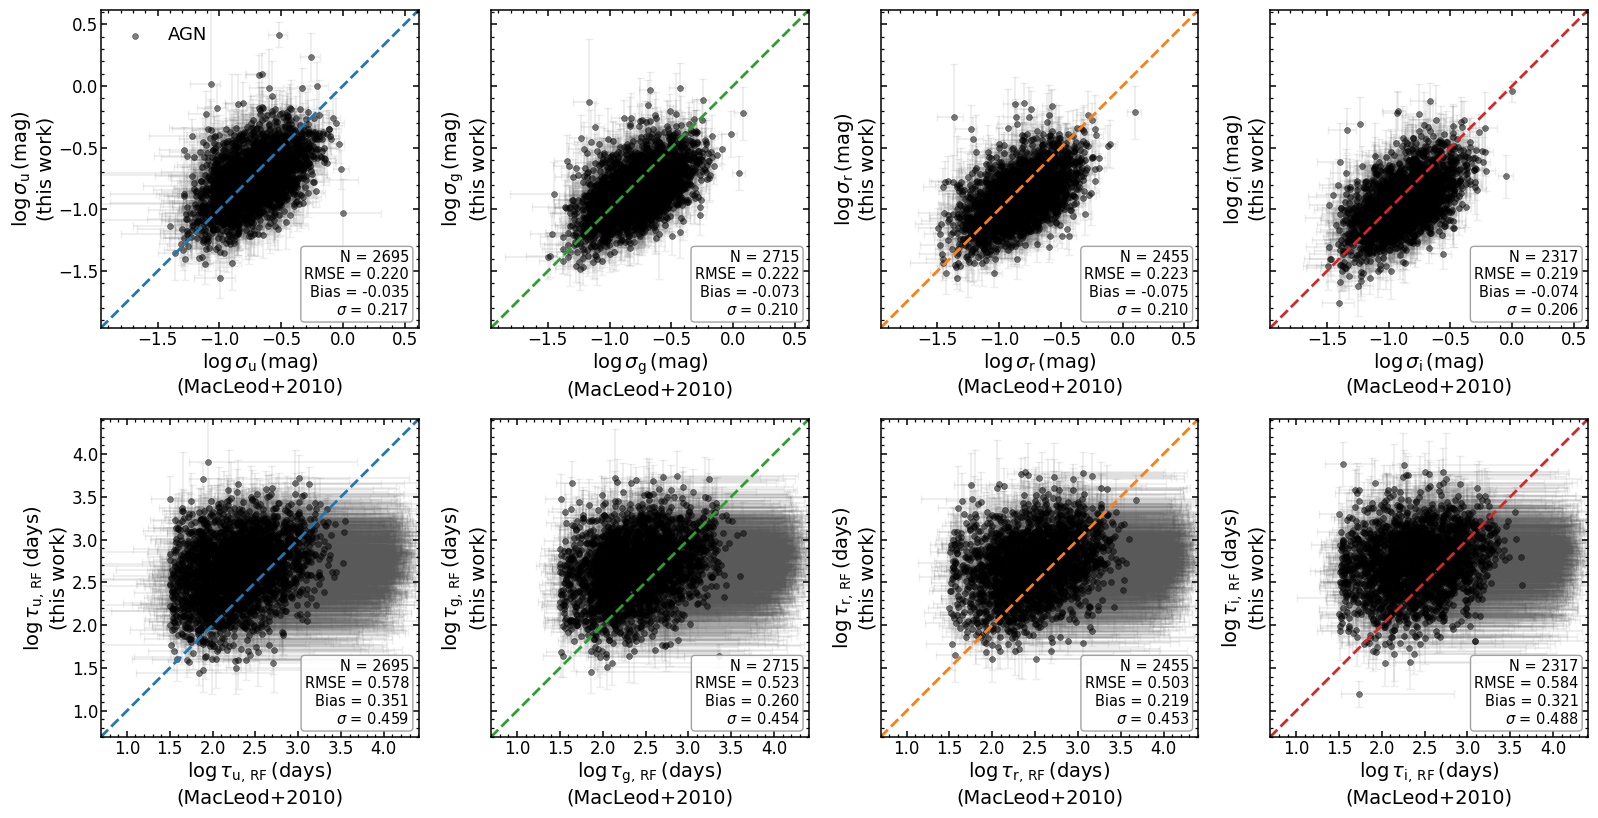

In [182]:
colors = {'u': 'tab:blue',
          'g': 'tab:green',
          'r': 'tab:orange',
          'i': 'tab:red',
          'z': 'tab:brown',
          'y': 'tab:gray'}

RHO_CMAP = 'viridis'


def _resolve_rho_columns(df, band):
    candidates = [
        (f"tau_fast_band_{band}", f"tau_slow_band_{band}"),
        (f"tau_fast_{band}", f"tau_slow_{band}"),
    ]
    for fast_col, slow_col in candidates:
        if fast_col in df.columns and slow_col in df.columns:
            return fast_col, slow_col
    raise KeyError(f"Could not find tau_fast/tau_slow columns for band '{band}'.")


def _extract_rho(df, band, mask):
    fast_col, slow_col = _resolve_rho_columns(df, band)
    tau_fast = pd.to_numeric(df[fast_col], errors='coerce').to_numpy(dtype=float)
    tau_slow = pd.to_numeric(df[slow_col], errors='coerce').to_numpy(dtype=float)
    rho = tau_fast / tau_slow
    valid = np.isfinite(rho) & np.isfinite(tau_fast) & np.isfinite(tau_slow) & (tau_fast > 0.0) & (tau_slow > 0.0)
    return rho[mask], valid[mask]


def _rho_norm_from_series(rho_series):
    finite = [rho[np.isfinite(rho) & (rho > 0.0)] for rho in rho_series if rho is not None]
    finite = [rho for rho in finite if rho.size > 0]
    if not finite:
        raise ValueError('No finite positive rho values available for color normalization.')
    rho_all = np.concatenate(finite)
    return plt.Normalize(vmin=np.nanmin(rho_all), vmax=np.nanmax(rho_all))


def _symmetrize_error(err):
    if err is None:
        return None
    if isinstance(err, tuple):
        low = np.asarray(err[0], dtype=float)
        high = np.asarray(err[1], dtype=float)
        sym = 0.5 * (np.abs(low) + np.abs(high))
    else:
        sym = np.asarray(err, dtype=float)
    valid = np.isfinite(sym) & (sym >= 0.0)
    return np.where(valid, sym, np.nan)


def _compute_panel_metrics(x, y, xerr=None, yerr=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if not np.any(mask):
        return None

    x = x[mask]
    y = y[mask]
    delta = y - x
    metrics = {
        'N': int(delta.size),
        'RMSE': float(np.sqrt(np.mean(delta ** 2))),
        'Bias': float(np.mean(delta)),
        'sigma': float(np.std(delta)),
    }

    xerr_sym = _symmetrize_error(xerr)
    yerr_sym = _symmetrize_error(yerr)
    if xerr_sym is not None and yerr_sym is not None:
        xerr_sym = xerr_sym[mask]
        yerr_sym = yerr_sym[mask]
        sigma_tot_sq = xerr_sym ** 2 + yerr_sym ** 2
        valid_chi = np.isfinite(sigma_tot_sq) & (sigma_tot_sq > 0.0)
        if np.any(valid_chi):
            metrics['chi2_nu'] = float(np.sum((delta[valid_chi] ** 2) / sigma_tot_sq[valid_chi]) / valid_chi.sum())
    return metrics


def _format_panel_metrics(metrics, *, header=None):
    if metrics is None:
        return None
    lines = []
    if header:
        lines.append(header)
    lines.extend([
        f"N = {metrics['N']}",
        f"RMSE = {metrics['RMSE']:.3f}",
        f"Bias = {metrics['Bias']:.3f}",
        f"$\sigma$ = {metrics['sigma']:.3f}",
    ])

    return "\n".join(lines)


def _annotate_panel_metrics(ax, metrics, *, loc='lower right', header=None, fontsize=8.5):
    text = _format_panel_metrics(metrics, header=header)
    if not text:
        return
    anchors = {
        'lower right': (0.97, 0.03, 'right', 'bottom'),
        'lower left': (0.03, 0.03, 'left', 'bottom'),
        'upper right': (0.97, 0.97, 'right', 'top'),
        'upper left': (0.03, 0.97, 'left', 'top'),
    }
    x, y, ha, va = anchors[loc]
    ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=fontsize,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.6', alpha=0.9),
        zorder=20,
    )


def plot_tau_identity_grid(matched_by_band, *, title, output_path):
    bands = ['u', 'g', 'r', 'i']
    label_fontsize = 14
    tick_fontsize = 12
    legend_fontsize = 13
    metric_fontsize = 10.5
    fig, axes = plt.subplots(2, 4, figsize=(16.0, 8.0), sharex='row', sharey='row', constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.01, wspace=0.0, hspace=0.05)

    def _style(ax):
        ax.minorticks_on()
        ax.tick_params(direction='in', which='major', top=True, right=True, length=4, width=1.1, pad=2, labelsize=tick_fontsize)
        ax.tick_params(direction='in', which='minor', top=True, right=True, length=2.5, width=0.9)
        for spine in ax.spines.values():
            spine.set_linewidth(1.1)
        ax.set_aspect('equal', adjustable='box')

    def _set_row_ticks(ax_row, quantity):
        if quantity == 'sigma':
            major = MultipleLocator(0.5)
            minor = AutoMinorLocator(5)
        else:
            major = MultipleLocator(0.5)
            minor = AutoMinorLocator(5)
        for ax in ax_row:
            ax.xaxis.set_major_locator(major)
            ax.yaxis.set_major_locator(major)
            ax.xaxis.set_minor_locator(minor)
            ax.yaxis.set_minor_locator(minor)

    def _row_limits(quantity):
        xmins = []
        xmaxs = []
        ymins = []
        ymaxs = []
        for band in bands:
            df_band = matched_by_band[band]
            x = pd.to_numeric(df_band[f"macleod_{quantity}_{band}"], errors="coerce").to_numpy(dtype=float)
            y = pd.to_numeric(df_band[f"ours_{quantity}_{band}"], errors="coerce").to_numpy(dtype=float)
            mask = np.isfinite(x) & np.isfinite(y)
            if np.any(mask):
                xmins.append(np.nanmin(x[mask]))
                xmaxs.append(np.nanmax(x[mask]))
                ymins.append(np.nanmin(y[mask]))
                ymaxs.append(np.nanmax(y[mask]))
        if not xmins:
            raise ValueError(f"No finite matched {quantity} values available for any band.")
        lo = min(xmins + ymins)
        hi = max(xmaxs + ymaxs)
        pad_floor = 0.2 if quantity == 'sigma' else 0.5
        pad = max(0.04 * (hi - lo), pad_floor)
        return (lo - pad, hi + pad)

    sigma_lims = _row_limits('sigma')
    tau_lims = _row_limits('tau')

    for col, band in enumerate(bands):
        df_band = matched_by_band[band]

        ax_sigma = axes[0, col]
        x_sigma = pd.to_numeric(df_band[f"macleod_sigma_{band}"], errors="coerce").to_numpy(dtype=float)
        y_sigma = pd.to_numeric(df_band[f"ours_sigma_{band}"], errors="coerce").to_numpy(dtype=float)
        yerr_sigma = pd.to_numeric(df_band[f"ours_sigma_{band}_err"], errors="coerce").to_numpy(dtype=float)
        sigma_lo = pd.to_numeric(df_band[f"macleod_sigma_lo_{band}"], errors="coerce").to_numpy(dtype=float)
        sigma_hi = pd.to_numeric(df_band[f"macleod_sigma_hi_{band}"], errors="coerce").to_numpy(dtype=float)
        xerr_low_sigma = x_sigma - sigma_lo
        xerr_high_sigma = sigma_hi - x_sigma
        valid_xerr_sigma = (
            np.isfinite(xerr_low_sigma) & np.isfinite(xerr_high_sigma)
            & (xerr_low_sigma >= 0.0) & (xerr_high_sigma >= 0.0)
        )
        valid_yerr_sigma = np.isfinite(yerr_sigma) & (yerr_sigma >= 0.0)
        mask_sigma = np.isfinite(x_sigma) & np.isfinite(y_sigma)

        ax_sigma.plot(sigma_lims, sigma_lims, ls='--', lw=2.0, color=colors.get(band, '0.2'), zorder=-4)
        ax_sigma.set_xlim(*sigma_lims)
        ax_sigma.set_ylim(*sigma_lims)
        _style(ax_sigma)

        if np.any(mask_sigma):
            x_sigma_plot = x_sigma[mask_sigma]
            y_sigma_plot = y_sigma[mask_sigma]
            xerr_low_sigma_plot = np.where(valid_xerr_sigma[mask_sigma], xerr_low_sigma[mask_sigma], np.nan)
            xerr_high_sigma_plot = np.where(valid_xerr_sigma[mask_sigma], xerr_high_sigma[mask_sigma], np.nan)
            yerr_sigma_plot = np.where(valid_yerr_sigma[mask_sigma], yerr_sigma[mask_sigma], np.nan)
            sigma_metrics = _compute_panel_metrics(x_sigma_plot, y_sigma_plot, xerr=(xerr_low_sigma_plot, xerr_high_sigma_plot), yerr=yerr_sigma_plot)
            ax_sigma.errorbar(x_sigma_plot, y_sigma_plot, xerr=[xerr_low_sigma_plot, xerr_high_sigma_plot], yerr=yerr_sigma_plot, fmt='none',
                        color='0.35', alpha=0.1, lw=1.4, capsize=3, capthick=1, zorder=-9)
            ax_sigma.scatter(x_sigma_plot, y_sigma_plot, color='k', s=18, alpha=0.5, edgecolor='k', linewidths=0.5, zorder=-8, label='AGN')

            _annotate_panel_metrics(ax_sigma, sigma_metrics, loc='lower right', fontsize=metric_fontsize)
        else:
            ax_sigma.text(0.5, 0.5, f"{band}-band\\nno matched data", transform=ax_sigma.transAxes, ha='center', va='center')

        ax_tau = axes[1, col]
        x_tau = pd.to_numeric(df_band[f"macleod_tau_{band}"], errors="coerce").to_numpy(dtype=float)
        y_tau = pd.to_numeric(df_band[f"ours_tau_{band}"], errors="coerce").to_numpy(dtype=float)
        yerr_tau = pd.to_numeric(df_band[f"ours_tau_{band}_err"], errors="coerce").to_numpy(dtype=float)
        tau_lo = pd.to_numeric(df_band[f"macleod_tau_lo_{band}"], errors="coerce").to_numpy(dtype=float)
        tau_hi = pd.to_numeric(df_band[f"macleod_tau_hi_{band}"], errors="coerce").to_numpy(dtype=float)
        xerr_low_tau = x_tau - tau_lo
        xerr_high_tau = tau_hi - x_tau
        valid_yerr_tau = np.isfinite(yerr_tau) & (yerr_tau >= 0.0)
        mask_tau = np.isfinite(x_tau) & np.isfinite(y_tau)

        ax_tau.plot(tau_lims, tau_lims, ls='--', lw=2.0, color=colors.get(band, '0.2'), zorder=-4)
        ax_tau.set_xlim(*tau_lims)
        ax_tau.set_ylim(*tau_lims)
        _style(ax_tau)

        if np.any(mask_tau):
            x_tau_plot = x_tau[mask_tau]
            y_tau_plot = y_tau[mask_tau]
            xerr_low_tau_plot = xerr_low_tau[mask_tau]
            xerr_high_tau_plot = xerr_high_tau[mask_tau]
            yerr_tau_plot = np.where(valid_yerr_tau[mask_tau], yerr_tau[mask_tau], np.nan)
            tau_metrics = _compute_panel_metrics(
                x_tau_plot,
                y_tau_plot,
                xerr=(xerr_low_tau_plot, xerr_high_tau_plot),
                yerr=yerr_tau_plot,
            )

            ax_tau.errorbar(x_tau_plot, y_tau_plot, xerr=[xerr_low_tau_plot, xerr_high_tau_plot], yerr=yerr_tau_plot, fmt='none',
                        color='0.35', alpha=0.1, lw=1.4, capsize=3, capthick=1, zorder=-9)
            ax_tau.scatter(x_tau_plot, y_tau_plot, color='k', s=18, alpha=0.5, edgecolor='k', linewidths=0.5, zorder=-8, label='AGN')
            _annotate_panel_metrics(ax_tau, tau_metrics, loc='lower right', fontsize=metric_fontsize)
        else:
            ax_tau.text(0.5, 0.5, f"{band}-band\\nno matched data", transform=ax_tau.transAxes, ha='center', va='center')


    _set_row_ticks(axes[0], 'sigma')
    _set_row_ticks(axes[1], 'tau')

    for col, band in enumerate(bands):
        axes[0, col].set_xlabel(r'$\log\!\,\sigma_{{\mathrm{{{band}}}}}\,(\mathrm{{mag}})$'.format(band=band) + '\n(MacLeod+2010)', labelpad=2, fontsize=label_fontsize)
        axes[0, col].set_ylabel(r'$\log\!\,\sigma_{{\mathrm{{{band}}}}}\,(\mathrm{{mag}})$'.format(band=band) + '\n(this work)', labelpad=2, fontsize=label_fontsize)
        axes[1, col].set_xlabel(r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$'.format(band=band) + '\n(MacLeod+2010)', labelpad=2, fontsize=label_fontsize)
        axes[1, col].set_ylabel(r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$'.format(band=band) + '\n(this work)', labelpad=2, fontsize=label_fontsize)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        axes[0, 0].legend(
            loc='upper left', frameon=False, fancybox=True, framealpha=1,
            edgecolor='0.2', facecolor='white', fontsize=legend_fontsize,
        )

    fig.savefig(output_path, dpi=600, bbox_inches='tight')
    return fig


# _ = plot_tau_identity_grid(
#     matched_by_band_all,
#     title="this work vs MacLeod+2010 tau by band: all matched",
#     output_path="../plots/hubble/diagnostics/tau_identity_this_work_vs_MacLeod2010_ugri_all_matched.pdf",
# )
plt.show()

_ = plot_tau_identity_grid(
    matched_by_band_subcut,
    title="this work vs MacLeod+2010 tau by band: MacLeod+2010 tau-cut subset",
    output_path="../plots/hubble/diagnostics/tau_identity_this_work_vs_MacLeod2010_ugri_MacLeod2010_tau_cut.pdf",
)
plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


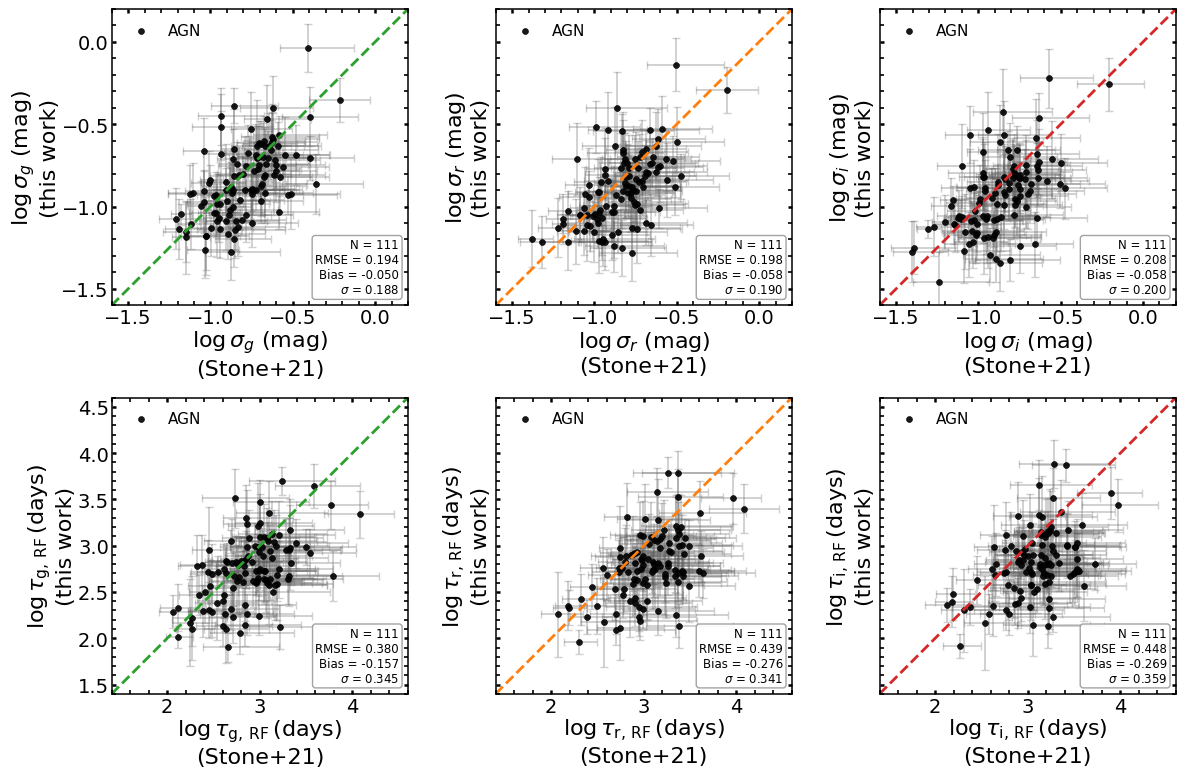

In [183]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import os
from qvc.hubble.hubble_utils import load_agn_data, read_quasars_from_hdf5_flat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.style.use('../src/qvc/hubble/style.mplstyle')

from scipy.stats import linregress
from matplotlib.lines import Line2D

colors = {'u': 'tab:blue',
          'g': 'tab:green',
          'r': 'tab:orange',
          'i': 'tab:red',
          'z': 'tab:brown',
          'y': 'tab:gray'}

def plot_stone_vs_this_work(
    merged_df,
    sigma_keys,
    tau_keys,
    bands=('g', 'r', 'i'),
    figsize=(12, 7.6),
    show=True,
    figfile='figures/appendix/stone.png',
    figure_title=None,
):

    ncols = len(bands)
    fig, axes = plt.subplots(2, ncols, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.01, wspace=0.0, hspace=0.05)

    axes = np.atleast_2d(axes)

    def _limits(x, y, pad=0.04):
        lo = np.nanmin([np.nanmin(x), np.nanmin(y)])
        hi = np.nanmax([np.nanmax(x), np.nanmax(y)])
        rng = max(hi - lo, 1e-6)
        return lo - pad * rng, hi + pad * rng

    def _style(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.1)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                loc='upper left', frameon=False, fancybox=True, framealpha=1,
                edgecolor='0.2', facecolor='white', fontsize=11,
            )

    def _resolve_pattern(df, pattern, band):
        if pattern is None:
            return None
        if isinstance(pattern, tuple):
            names = [item.format(band=band) for item in pattern]
            if not all(name in df.columns for name in names):
                return None
            return tuple(df[name].to_numpy(dtype=float) for name in names)
        name = pattern.format(band=band)
        if name not in df.columns:
            return None
        return df[name].to_numpy(dtype=float)

    def _resolve_label(template, band):
        if template is None:
            return None
        return template.replace('<<band>>', band)

    def _extract_xyerr(df, keydict, band):
        x = _resolve_pattern(df, keydict['x'], band)
        y = _resolve_pattern(df, keydict['y'], band)
        if x is None or y is None:
            return None, 'missing data'
        xerr = _resolve_pattern(df, keydict.get('xerr'), band)
        yerr = _resolve_pattern(df, keydict.get('yerr'), band)

        m = np.isfinite(x) & np.isfinite(y)
        if isinstance(xerr, tuple):
            m &= np.isfinite(xerr[0]) & np.isfinite(xerr[1])
        elif xerr is not None:
            m &= np.isfinite(xerr)
        if isinstance(yerr, tuple):
            m &= np.isfinite(yerr[0]) & np.isfinite(yerr[1])
        elif yerr is not None:
            m &= np.isfinite(yerr)

        if m.sum() == 0:
            return None, 'no finite matched data'

        x, y = x[m], y[m]
        if isinstance(xerr, tuple):
            xerr = (xerr[0][m], xerr[1][m])
        elif xerr is not None:
            xerr = xerr[m]
        if isinstance(yerr, tuple):
            yerr = (yerr[0][m], yerr[1][m])
        elif yerr is not None:
            yerr = yerr[m]
        return (x, y, xerr, yerr), None

    # ---------- Top row: σ ----------
    for ax, band in zip(axes[0], bands):
        data, message = _extract_xyerr(merged_df, sigma_keys, band)
        if data is None:
            _style(ax)
            ax.text(0.5, 0.5, f"{band}-band\n{message}", transform=ax.transAxes, ha='center', va='center')
            continue
        x, y, xerr, yerr = data
        metrics = _compute_panel_metrics(x, y, xerr=xerr, yerr=yerr)

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, color='k', s=18, alpha=0.9, edgecolor='k', linewidths=0.5, zorder=-8, label='AGN')

        xmin, xmax = _limits(x, y)
        xmin, xmax = (-1.6, 0.2)
        line_color = colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color, zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(_resolve_label(sigma_keys.get('xlabel'), band), labelpad=1)
        ax.set_ylabel(_resolve_label(sigma_keys.get('ylabel'), band), labelpad=1)
        _annotate_panel_metrics(ax, metrics, loc='lower right')
        _style(ax)

    # ---------- Bottom row: τ ----------
    for ax, band in zip(axes[1], bands):
        data, message = _extract_xyerr(merged_df, tau_keys, band)
        if data is None:
            _style(ax)
            ax.text(0.5, 0.5, f"{band}-band\n{message}", transform=ax.transAxes, ha='center', va='center')
            continue
        x, y, xerr, yerr = data
        metrics = _compute_panel_metrics(x, y, xerr=xerr, yerr=yerr)

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, color='k', s=18, alpha=0.9, edgecolor='k', linewidths=0.5, zorder=-8, label='AGN')

        xmin, xmax = _limits(x, y)
        xmin, xmax = (1.4, 4.6)
        line_color = colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color, zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(_resolve_label(tau_keys.get('xlabel'), band), labelpad=1)
        ax.set_ylabel(_resolve_label(tau_keys.get('ylabel'), band), labelpad=1)
        _annotate_panel_metrics(ax, metrics, loc='lower right')
        _style(ax)

    for i in range(2):
        for j in range(1, ncols):
            axes[i, j].tick_params(labelleft=False)


    fig.savefig(figfile, dpi=600)


    if show:
        plt.show()
    plt.close(fig)


sigma_keys_raw = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log\!\,\sigma_<<band>>$ (mag)' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\sigma_<<band>>$ (mag)' + '\n(this work)',
}

tau_keys_raw = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(this work)',
}



# Load Stone+21 data from FITS and match onto the S82 object ids used by this work
stone_fits_path = Path('../data/Stone2021/TotalDat.fits')
with fits.open(stone_fits_path, memmap=False) as hdul:
    stone_data = hdul[1].data

stone_rows = []
for i in range(len(stone_data)):
    row = {
        'stone_DBID': stone_data['DBID'][i],
        'stone_RA': stone_data['RA'][i],
        'stone_DEC': stone_data['DEC'][i],
        'stone_Z': stone_data['Z'][i],
    }
    for band in ('g', 'r', 'i'):
        row |= {
            f'stone_log_SIGMA_{band}': stone_data[f'log_SIGMA_{band}'][i],
            f'stone_log_SIGMA_{band}_ERR_L': stone_data[f'log_SIGMA_{band}_ERR_L'][i],
            f'stone_log_SIGMA_{band}_ERR_U': stone_data[f'log_SIGMA_{band}_ERR_U'][i],
            f'stone_log_TAU_REST_{band}': stone_data[f'log_TAU_REST_{band}'][i],
            f'stone_log_TAU_REST_{band}_ERR_L': stone_data[f'log_TAU_REST_{band}_ERR_L'][i],
            f'stone_log_TAU_REST_{band}_ERR_U': stone_data[f'log_TAU_REST_{band}_ERR_U'][i],
        }
    stone_rows.append(row)

stone_df = pd.DataFrame(stone_rows)

cat = pd.read_parquet('../data/S82/Catalog.parquet').reset_index()
stone_coords = SkyCoord(ra=stone_df['stone_RA'].to_numpy() * u.deg, dec=stone_df['stone_DEC'].to_numpy() * u.deg)
cat_coords = SkyCoord(ra=cat['RA'].to_numpy() * u.deg, dec=cat['DEC'].to_numpy() * u.deg)
idx, d2d, _ = stone_coords.match_to_catalog_sky(cat_coords)
match_mask = d2d < 1.0 * u.arcsec

stone_df = stone_df.loc[match_mask].copy()
stone_df['object_id'] = cat.iloc[idx[match_mask]]['objectId'].astype(str).to_numpy()
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)


os.makedirs("figures/appendix/stone_tests", exist_ok=True)
merged_agn_stone = pd.merge(stone_df, df_agn, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_stone_vs_this_work(
    merged_agn_stone,
    sigma_keys_raw,
    tau_keys_raw,
    bands=('g', 'r', 'i'),
    figfile='figures/appendix/stone_fitted_band_fields.pdf',
)


stone_r_overlay = merged_agn_stone.rename(columns={
    'stone_log_SIGMA_r': 'stone_sigma_r',
    'stone_log_TAU_REST_r': 'stone_tau_r',
}).copy()


In [184]:
def plot_sigma_tau_style_comparison(ours_df, comparison_df, *, title=None, comparison_overlays=None):
    ours_sigma = pd.to_numeric(ours_df['ours_sigma_r'], errors='coerce').to_numpy(dtype=float)
    ours_tau = pd.to_numeric(ours_df['ours_tau_r'], errors='coerce').to_numpy(dtype=float)

    ours_mask = np.isfinite(ours_sigma) & np.isfinite(ours_tau)
    ours_idx = np.flatnonzero(ours_mask)

    if comparison_overlays is None:
        comparison_overlays = [
            {
                'dataframe': comparison_df,
                'sigma_col': 'macleod_sigma_r',
                'tau_col': 'macleod_tau_r',
                'label': 'MacLeod+2010',
                'color': 'tab:orange',
            },
        ]

    processed_overlays = []
    for overlay in comparison_overlays:
        overlay_sigma = pd.to_numeric(overlay['dataframe'][overlay['sigma_col']], errors='coerce').to_numpy(dtype=float)
        overlay_tau = pd.to_numeric(overlay['dataframe'][overlay['tau_col']], errors='coerce').to_numpy(dtype=float)
        overlay_mask = np.isfinite(overlay_sigma) & np.isfinite(overlay_tau) & (overlay_sigma > -9) & (overlay_tau > -9) & (overlay_tau < 5)
        overlay_idx = np.flatnonzero(overlay_mask)
        processed_overlays.append({
            'sigma': overlay_sigma,
            'tau': overlay_tau,
            'idx': overlay_idx,
            'label': overlay['label'],
            'color': overlay['color'],
        })

    overlay_hist_x_positions = [0.77, 0.64, 0.51]
    tau_hist_x_positions = [0.98, 0.82, 0.66]

    summary_metric_blocks = []

    fig = plt.figure(figsize=(7.8, 7.0))
    gs = fig.add_gridspec(2, 2, width_ratios=(4.0, 1.2), height_ratios=(1.2, 4.0), hspace=0.05, wspace=0.05)
    ax_hist_x = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_hist_x)
    ax_hist_y = fig.add_subplot(gs[1, 1], sharey=ax)

    if ours_idx.size > 0:
        ax.scatter(
            ours_sigma[ours_idx],
            ours_tau[ours_idx],
            s=2.2**2,
            color='0.3',
            alpha=0.7,
            linewidths=0,
            rasterized=True,
            label='this work',
        )
        sigma_med = np.nanmedian(ours_sigma[ours_idx])
        tau_med = np.nanmedian(ours_tau[ours_idx])
        sigma_med_linear = 10.0 ** sigma_med
        tau_med_linear = 10.0 ** tau_med
        ax_hist_x.hist(ours_sigma[ours_idx], bins=30, color='0.35', histtype='stepfilled', alpha=0.25)
        ax_hist_x.axvline(sigma_med, color='k', ls='--', lw=1.5)
        ax_hist_x.text(0.98, 0.90, f'this work: {sigma_med_linear:.2f} mag', ha='right', va='top', color='k', transform=ax_hist_x.transAxes, fontsize=9)
        ax_hist_y.hist(ours_tau[ours_idx], bins=30, orientation='horizontal', color='0.35', histtype='stepfilled', alpha=0.25)
        ax_hist_y.axhline(tau_med, color='k', ls='--', lw=1.5)
        ax_hist_y.text(tau_hist_x_positions[0]-0.05, 0.98, f'this work: {int(np.round(tau_med_linear))} days', ha='right', va='top', rotation=-90, color='k', transform=ax_hist_y.transAxes, fontsize=9)
        ours_metrics = _compute_panel_metrics(ours_sigma[ours_idx], ours_tau[ours_idx])
        summary_metric_blocks.append(_format_panel_metrics(ours_metrics, header='this work'))

    for overlay_index, overlay in enumerate(processed_overlays):
        overlay_idx = overlay['idx']
        if overlay_idx.size == 0:
            continue
        overlay_sigma = overlay['sigma']
        overlay_tau = overlay['tau']
        overlay_color = overlay['color']
        overlay_label = overlay['label']
        ax.scatter(overlay_sigma[overlay_idx], overlay_tau[overlay_idx], s=8, alpha=0.35, linewidths=0, color=overlay_color, rasterized=True, label=overlay_label)
        ax_hist_x.hist(overlay_sigma[overlay_idx], bins=30, color=overlay_color, histtype='step', lw=1.5, alpha=0.9)
        ax_hist_y.hist(overlay_tau[overlay_idx], bins=30, orientation='horizontal', color=overlay_color, histtype='step', lw=1.5, alpha=0.9)
        overlay_sigma_med = np.nanmedian(overlay_sigma[overlay_idx])
        overlay_tau_med = np.nanmedian(overlay_tau[overlay_idx])
        ax_hist_x.axvline(overlay_sigma_med, color=overlay_color, ls='--', lw=1.5)
        ax_hist_y.axhline(overlay_tau_med, color=overlay_color, ls='--', lw=1.5)
        overlay_sigma_med_linear = 10.0 ** overlay_sigma_med
        overlay_tau_med_linear = 10.0 ** overlay_tau_med
        hist_x_y = overlay_hist_x_positions[min(overlay_index, len(overlay_hist_x_positions) - 1)]
        tau_hist_x = tau_hist_x_positions[min(overlay_index + 1, len(tau_hist_x_positions) - 1)]
        ax_hist_x.text(0.98, hist_x_y, f'{overlay_label}: {overlay_sigma_med_linear:.2f} mag', ha='right', va='top', color=overlay_color, transform=ax_hist_x.transAxes, fontsize=9)
        ax_hist_y.text(tau_hist_x-0.05, 0.98, f'{overlay_label}: {int(np.round(overlay_tau_med_linear))} days', ha='right', va='top', rotation=-90, color=overlay_color, transform=ax_hist_y.transAxes, fontsize=9)
        overlay_metrics = _compute_panel_metrics(overlay_sigma[overlay_idx], overlay_tau[overlay_idx])
        summary_metric_blocks.append(_format_panel_metrics(overlay_metrics, header=overlay_label))

    combined_sigma_series = [ours_sigma[ours_idx]]
    combined_tau_series = [ours_tau[ours_idx]]
    for overlay in processed_overlays:
        if overlay['idx'].size > 0:
            combined_sigma_series.append(overlay['sigma'][overlay['idx']])
            combined_tau_series.append(overlay['tau'][overlay['idx']])
    combined_sigma = np.concatenate(combined_sigma_series) if combined_sigma_series else np.array([])
    combined_tau = np.concatenate(combined_tau_series) if combined_tau_series else np.array([])
    if combined_sigma.size and combined_tau.size:
        xpad = 0.05 * max(np.nanmax(combined_sigma) - np.nanmin(combined_sigma), 1e-6)
        ypad = 0.05 * max(np.nanmax(combined_tau) - np.nanmin(combined_tau), 1e-6)
        ax.set_xlim(np.nanmin(combined_sigma) - xpad, np.nanmax(combined_sigma) + xpad)
        ax.set_ylim(1.1, 4.9)

    ax.set_xlabel(r'$\log \sigma_{\rm UV}$')
    ax.set_ylabel(r'$\log \tau_{\rm UV,RF}$')
    ax.legend(loc='lower right')

    ax_hist_x.tick_params(labelbottom=False)
    ax_hist_y.tick_params(labelleft=False)
    ax_hist_x.set_ylabel('N')
    ax_hist_y.set_xlabel('N')
    fig.tight_layout()
    return fig


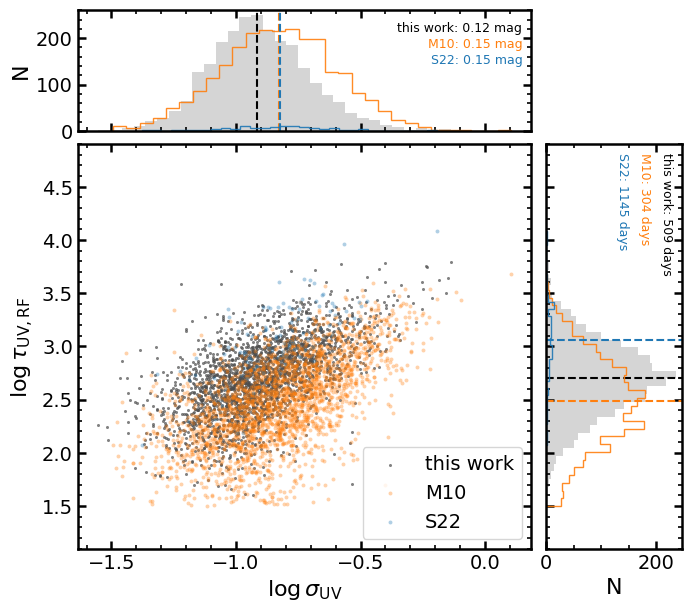

In [185]:
_ = plot_sigma_tau_style_comparison(
    matched_r_subcut,
    matched_r_subcut,
    title=None,
    comparison_overlays=[
        {
            'dataframe': matched_r_subcut,
            'sigma_col': 'macleod_sigma_r',
            'tau_col': 'macleod_tau_r',
            'label': 'M10',
            'color': 'tab:orange',
        },
        {
            'dataframe': stone_r_overlay,
            'sigma_col': 'stone_sigma_r',
            'tau_col': 'stone_tau_r',
            'label': 'S22',
            'color': 'tab:blue',
        },
    ],
)
plt.savefig("../plots/hubble/diagnostics/sigma_tau_comparison_this_work_vs_MacLeod2010_Stone2022_r.pdf", dpi=300)
plt.show()
